In [1]:
import pandas as pd

df = pd.read_csv('../data/uac_data.csv')

In [2]:
df = df.dropna()

df['Date'] = pd.to_datetime(df['Date'])

df['Children in HHS Care'] = (
    df['Children in HHS Care']
    .str.replace(',', '')
    .astype(float)
)

df = df.sort_values('Date')

df.set_index('Date', inplace=True)

In [3]:
df['lag_1'] = df['Children in HHS Care'].shift(1)

In [4]:
df['lag_7'] = df['Children in HHS Care'].shift(7)

In [5]:
df['lag_14'] = df['Children in HHS Care'].shift(14)

In [6]:
df[['Children in HHS Care',
    'lag_1',
    'lag_7',
    'lag_14']].head(20)

,Children in HHS Care,lag_1,lag_7,lag_14
Date,,,,
2023-01-12,6566.0,NaN,NaN,NaN
2023-01-22,7122.0,6566.0,NaN,NaN
2023-01-23,7280.0,7122.0,NaN,NaN
2023-01-24,7433.0,7280.0,NaN,NaN
2023-01-25,7538.0,7433.0,NaN,NaN
2023-01-29,7472.0,7538.0,NaN,NaN
2023-01-30,7743.0,7472.0,NaN,NaN
2023-01-31,7803.0,7743.0,6566.0,NaN
2023-02-01,7903.0,7803.0,7122.0,NaN


In [7]:
df['rolling_mean_7'] = (
    df['Children in HHS Care']
    .rolling(window=7)
    .mean()
)

In [8]:
df['rolling_mean_14'] = (
    df['Children in HHS Care']
    .rolling(window=14)
    .mean()
)

In [9]:
df['rolling_std_7'] = (
    df['Children in HHS Care']
    .rolling(window=7)
    .std()
)

In [10]:
df['net_pressure'] = (
    df['Children transferred out of CBP custody']
    -
    df['Children discharged from HHS Care']
)

In [11]:
df['dayofweek'] = df.index.dayofweek

In [12]:
df['month'] = df.index.month

In [13]:
df['weekofyear'] = df.index.isocalendar().week

In [14]:
df.dropna(inplace=True)

In [15]:
df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_std_7,net_pressure,dayofweek,month,weekofyear
Date,,,,,,,,,,,,,,,
2023-02-09,124.0,234.0,161.0,7908.0,353.0,7915.0,7803.0,6566.0,7823.714286,7654.071429,124.514677,-192.0,3,2,6
2023-02-12,92.0,203.0,173.0,7434.0,317.0,7908.0,7903.0,7122.0,7756.714286,7676.357143,185.827621,-144.0,6,2,6
2023-02-13,186.0,259.0,172.0,7483.0,244.0,7434.0,7879.0,7280.0,7700.142857,7690.857143,201.971474,-72.0,0,2,7
2023-02-14,154.0,225.0,220.0,7794.0,223.0,7483.0,7586.0,7433.0,7729.857143,7716.642857,197.633861,-3.0,1,2,7
2023-02-15,91.0,199.0,172.0,7869.0,290.0,7794.0,7720.0,7538.0,7751.142857,7740.285714,204.306492,-118.0,2,2,7


In [16]:
df.shape

(706, 15)

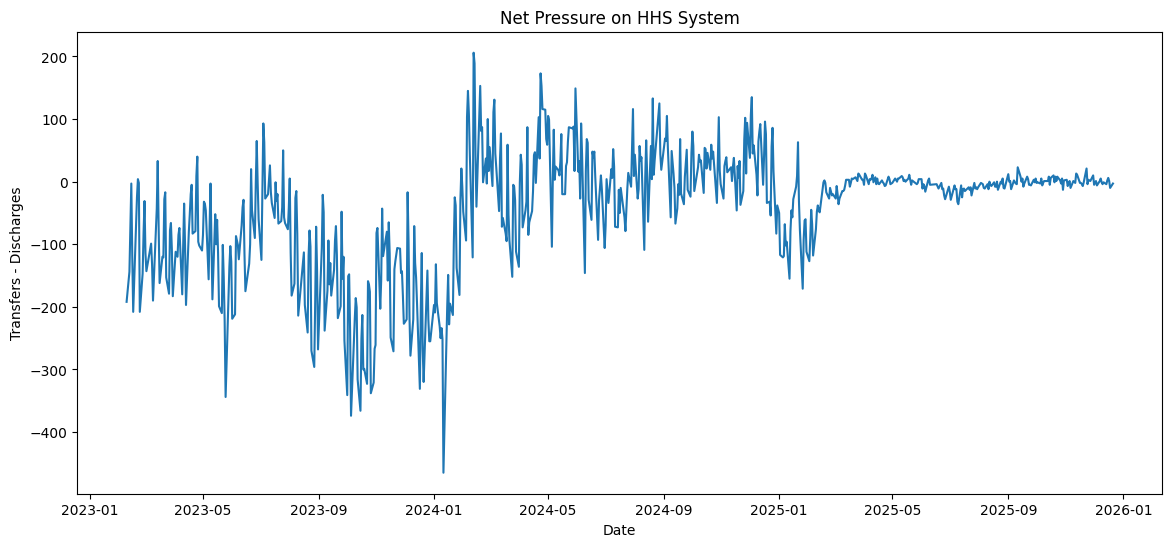

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df['net_pressure'])

plt.title("Net Pressure on HHS System")

plt.xlabel("Date")

plt.ylabel("Transfers - Discharges")

plt.show()

In [18]:
features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_std_7',
    'net_pressure',
    'dayofweek',
    'month'
]

In [19]:
X = df[features]

y = df['Children in HHS Care']

In [20]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
rf_preds = rf.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

mae = mean_absolute_error(y_test, rf_preds)

rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 63.97352112676057
RMSE: 86.20813057632552


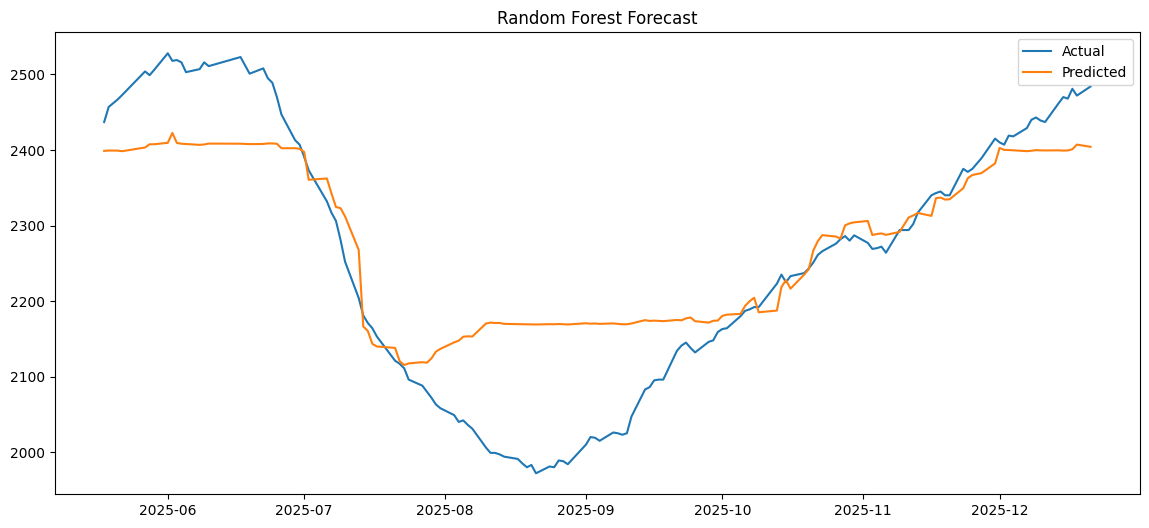

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(y_test.index,
         y_test,
         label='Actual')

plt.plot(y_test.index,
         rf_preds,
         label='Predicted')

plt.legend()

plt.title("Random Forest Forecast")

plt.show()

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()

gb.fit(X_train, y_train)

gb_preds = gb.predict(X_test)

In [26]:
mae_gb = mean_absolute_error(y_test, gb_preds)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, gb_preds)
)

print(mae_gb)
print(rmse_gb)

60.99807059573589
81.65243202099676


In [27]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting'
    ],
    
    'MAE': [
        mae,
        mae_gb
    ],
    
    'RMSE': [
        rmse,
        rmse_gb
    ]
})

print(comparison)

               Model        MAE       RMSE
0      Random Forest  63.973521  86.208131
1  Gradient Boosting  60.998071  81.652432


In [29]:
importance = rf.feature_importances_

In [30]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

           Feature  Importance
0            lag_1    0.714457
3   rolling_mean_7    0.213509
4  rolling_mean_14    0.033299
1            lag_7    0.030279
2           lag_14    0.005579
8            month    0.001068
6     net_pressure    0.000685
5    rolling_std_7    0.000641
7        dayofweek    0.000482


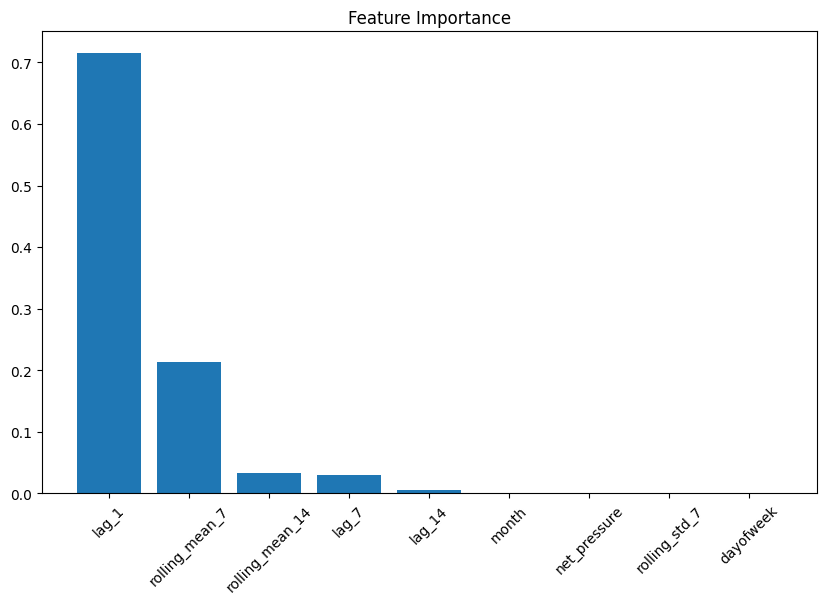

In [31]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [32]:
series = df['Children in HHS Care']

In [33]:
train_size = int(len(series) * 0.8)

train = series.iloc[:train_size]

test = series.iloc[train_size:]

In [34]:
from statsmodels.tsa.arima.model import ARIMA

In [35]:
model = ARIMA(
    train,
    order=(5,1,2)
)

c:\Users\alekh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\alekh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\alekh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [36]:
model_fit = model.fit()

In [37]:
forecast = model_fit.forecast(
    steps=len(test)
)

c:\Users\alekh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\alekh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


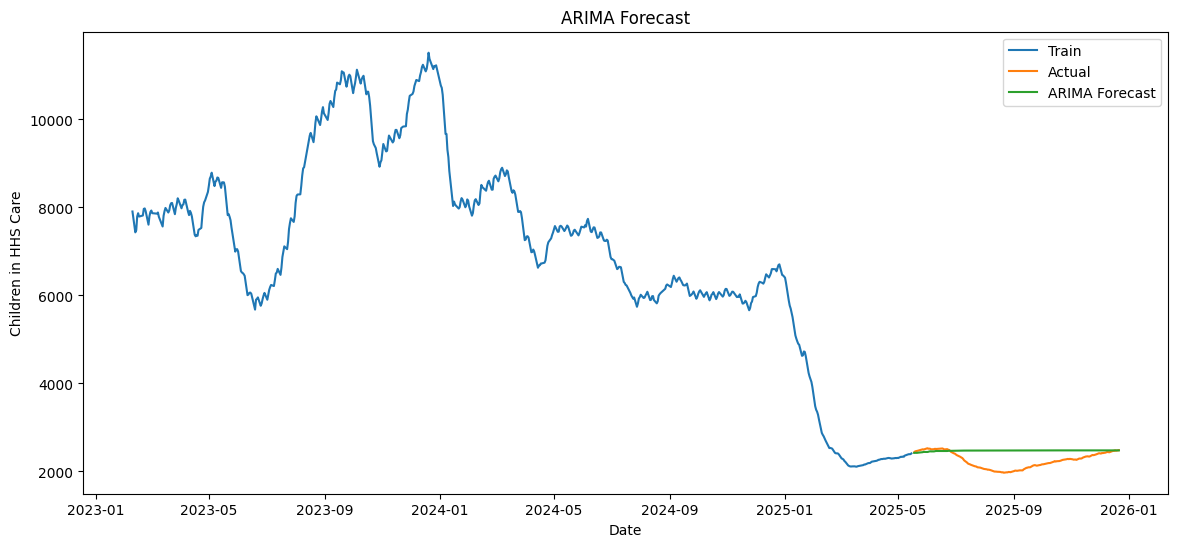

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train,
    label='Train'
)

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    forecast,
    label='ARIMA Forecast'
)

plt.legend()

plt.title("ARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Children in HHS Care")

plt.show()

In [39]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

In [40]:
mae_arima = mean_absolute_error(
    test,
    forecast
)

In [41]:
rmse_arima = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

In [42]:
print("ARIMA MAE:", mae_arima)

print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 240.49524759510714
ARIMA RMSE: 290.87922600498734


In [43]:
comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting',
        'ARIMA'
    ],
    
    'MAE': [
        mae,
        mae_gb,
        mae_arima
    ],
    
    'RMSE': [
        rmse,
        rmse_gb,
        rmse_arima
    ]
})

print(comparison)

               Model         MAE        RMSE
0      Random Forest   63.973521   86.208131
1  Gradient Boosting   60.998071   81.652432
2              ARIMA  240.495248  290.879226


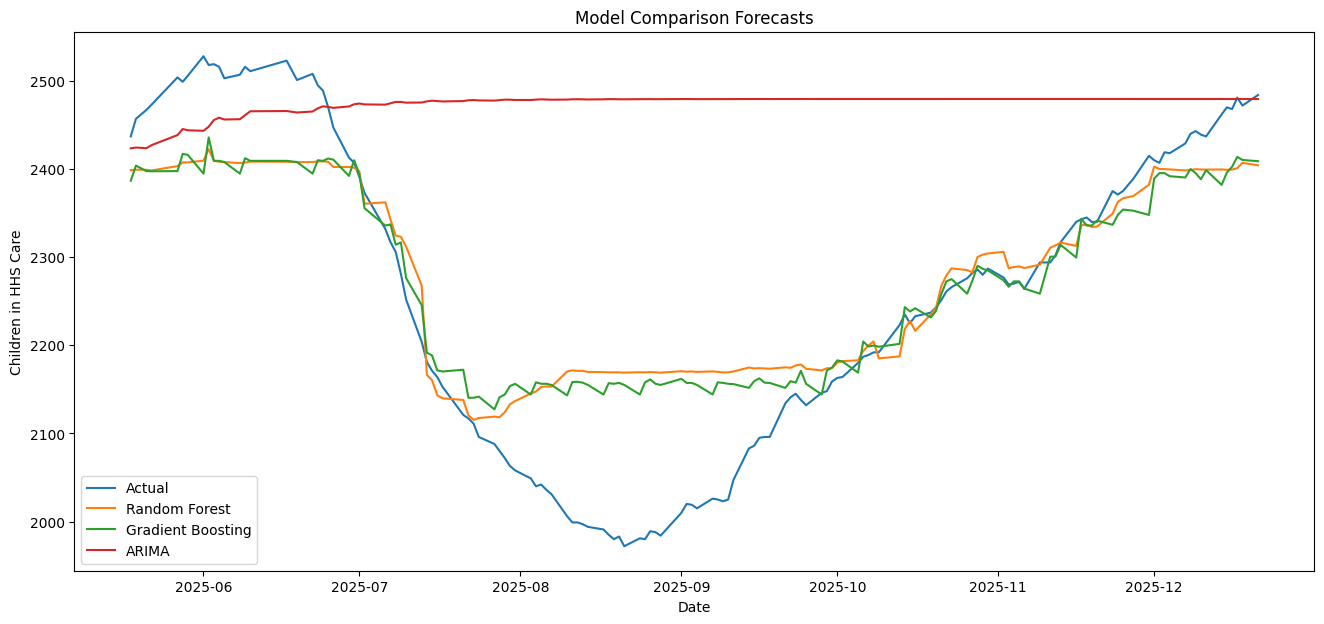

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,7))

plt.plot(
    y_test.index,
    y_test,
    label='Actual'
)

plt.plot(
    y_test.index,
    rf_preds,
    label='Random Forest'
)

plt.plot(
    y_test.index,
    gb_preds,
    label='Gradient Boosting'
)

plt.plot(
    test.index,
    forecast,
    label='ARIMA'
)

plt.legend()

plt.title("Model Comparison Forecasts")

plt.xlabel("Date")

plt.ylabel("Children in HHS Care")

plt.show()

In [45]:
forecast_obj = model_fit.get_forecast(
    steps=len(test)
)

conf_int = forecast_obj.conf_int()

c:\Users\alekh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\alekh\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [46]:
print(conf_int.head())

     lower Children in HHS Care  upper Children in HHS Care
564                 2194.421696                 2652.480894
565                 2092.794228                 2755.973657
566                 2006.214722                 2841.032382
567                 1935.689628                 2918.446673
568                 1861.373872                 3015.682555


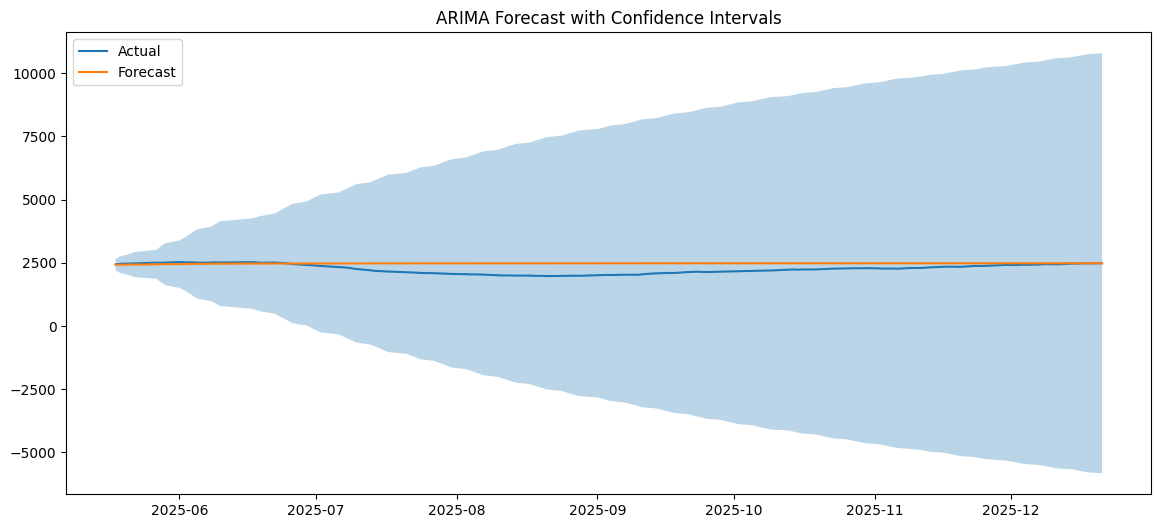

In [47]:
plt.figure(figsize=(14,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    forecast,
    label='Forecast'
)

plt.fill_between(
    test.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.3
)

plt.legend()

plt.title("ARIMA Forecast with Confidence Intervals")

plt.show()

In [48]:
from sklearn.metrics import mean_absolute_percentage_error

In [49]:
mape = mean_absolute_percentage_error(
    y_test,
    gb_preds
)

In [50]:
forecast_accuracy = 100 - (mape * 100)

print("Forecast Accuracy:", forecast_accuracy)

Forecast Accuracy: 97.18657939234969


In [51]:
threshold = df['Children in HHS Care'].quantile(0.90)

print(threshold)

9783.0


In [52]:
breach_days = gb_preds > threshold

In [53]:
print("Potential Breach Days:")

print(breach_days.sum())

Potential Breach Days:
0


In [54]:
surge_threshold = (
    df['net_pressure'].mean()
    +
    2 * df['net_pressure'].std()
)

In [55]:
df['surge_warning'] = (
    df['net_pressure']
    > surge_threshold
)

In [56]:
print(df['surge_warning'].sum())

6


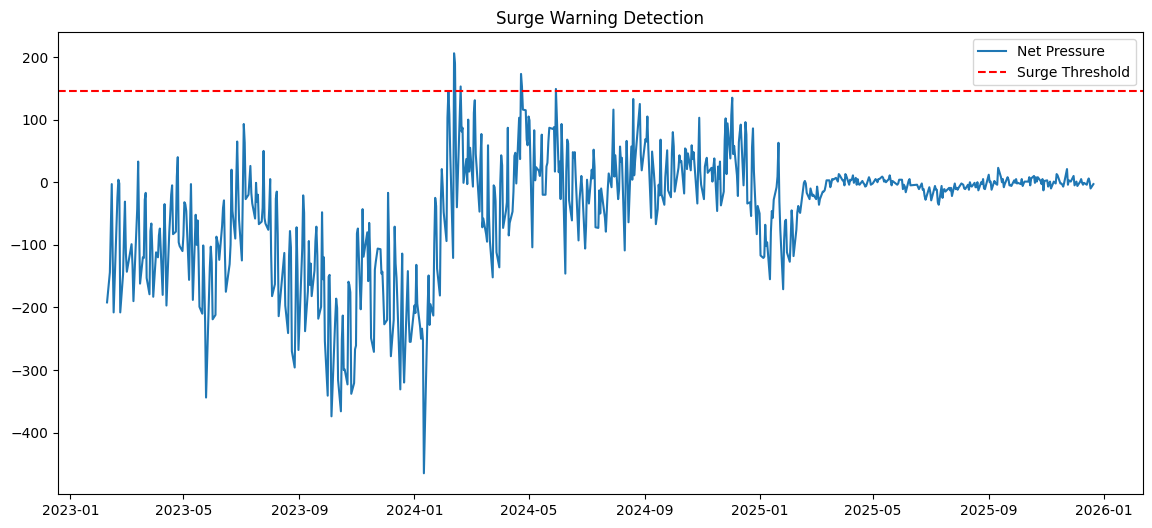

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['net_pressure'],
    label='Net Pressure'
)

plt.axhline(
    surge_threshold,
    color='red',
    linestyle='--',
    label='Surge Threshold'
)

plt.legend()

plt.title("Surge Warning Detection")

plt.show()

In [58]:
forecast_std = np.std(gb_preds)

print(forecast_std)

104.5138591245361
